# Diabetes: Case Study

### Dataset installation

In [ ]:
!curl -L -o ./diabetes-health-indicators-dataset.zip https://www.kaggle.com/api/v1/datasets/download/alexteboul/diabetes-health-indicators-dataset

### Import packages

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, make_scorer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.metrics import geometric_mean_score
from xgboost import XGBClassifier
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

### General information

In [97]:
df = pd.read_csv("./diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv")

In [98]:
rows , col =  df.shape
print(f"Number of Rows : {rows} \nNumber of Columns : {col}")

Number of Rows : 253680 
Number of Columns : 22


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [100]:
df.isna().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

### Data visualization

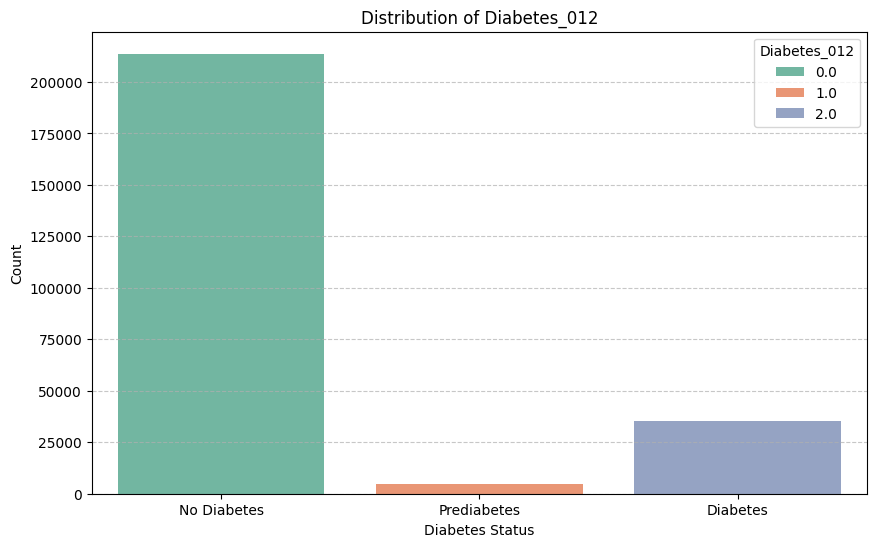

In [101]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Diabetes_012", data=df, hue="Diabetes_012", palette="Set2")
plt.title("Distribution of Diabetes_012")
plt.xticks([0, 1, 2], ["No Diabetes", "Prediabetes", "Diabetes"])
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

**Note:** We can see very strong imbalance in decision classes as patients without diabetes outnumber those with prediabetes and diabetes. 

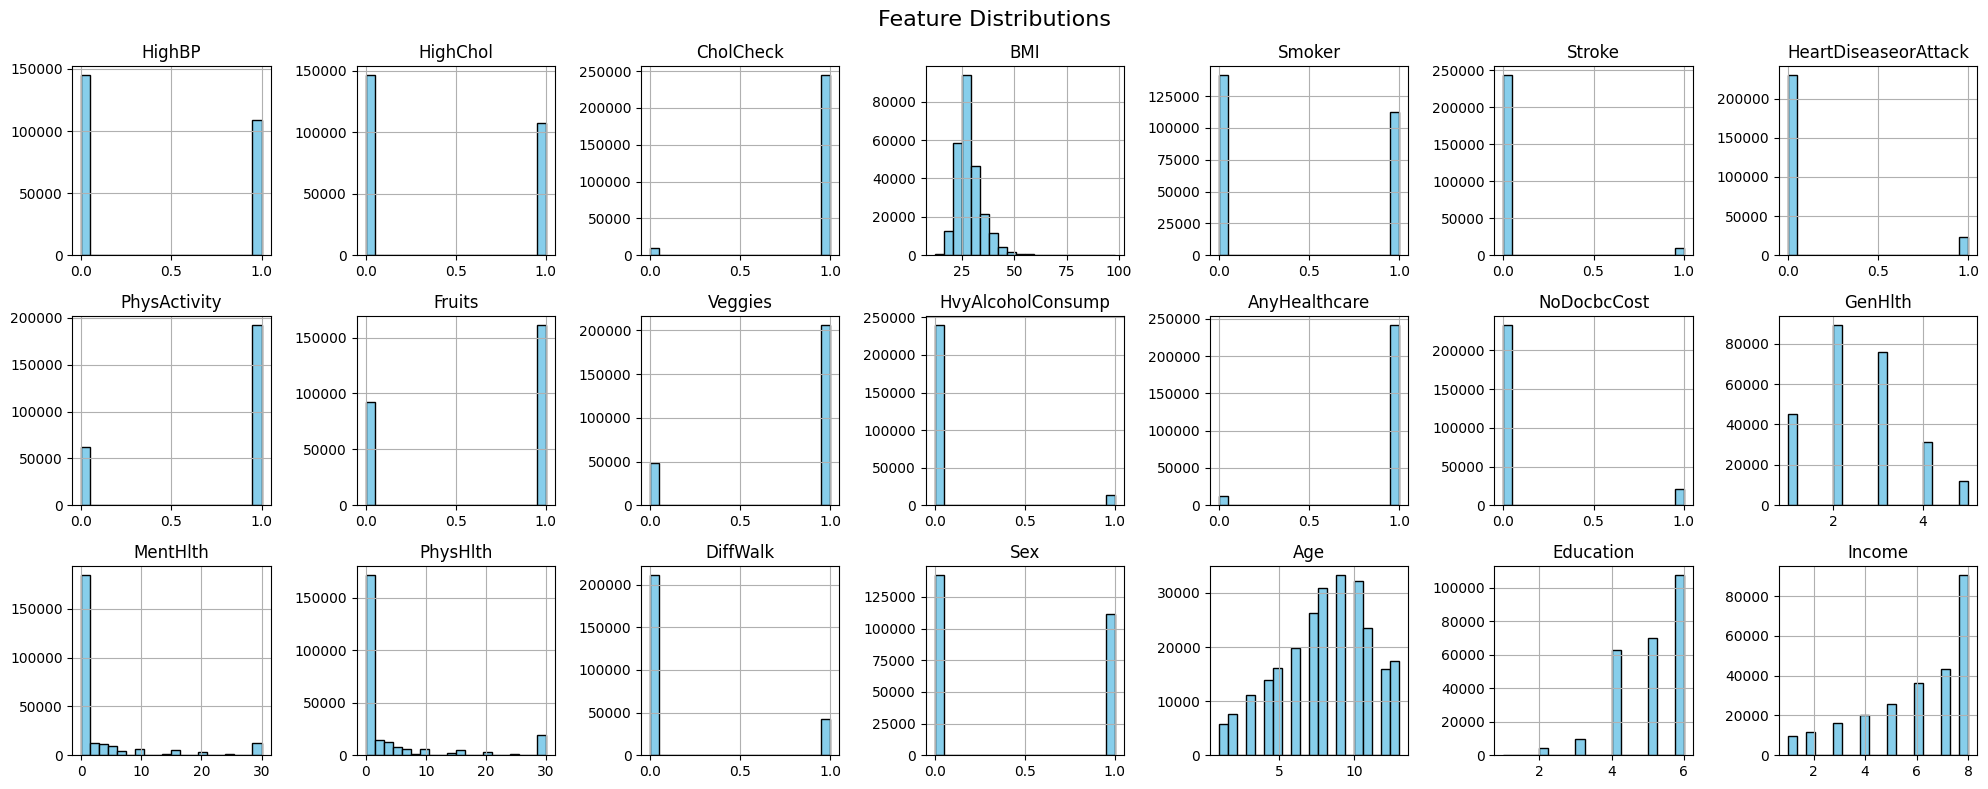

In [102]:
df.drop(['Diabetes_012'], axis=1).hist(figsize=(20, 8), layout=(3, 7), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

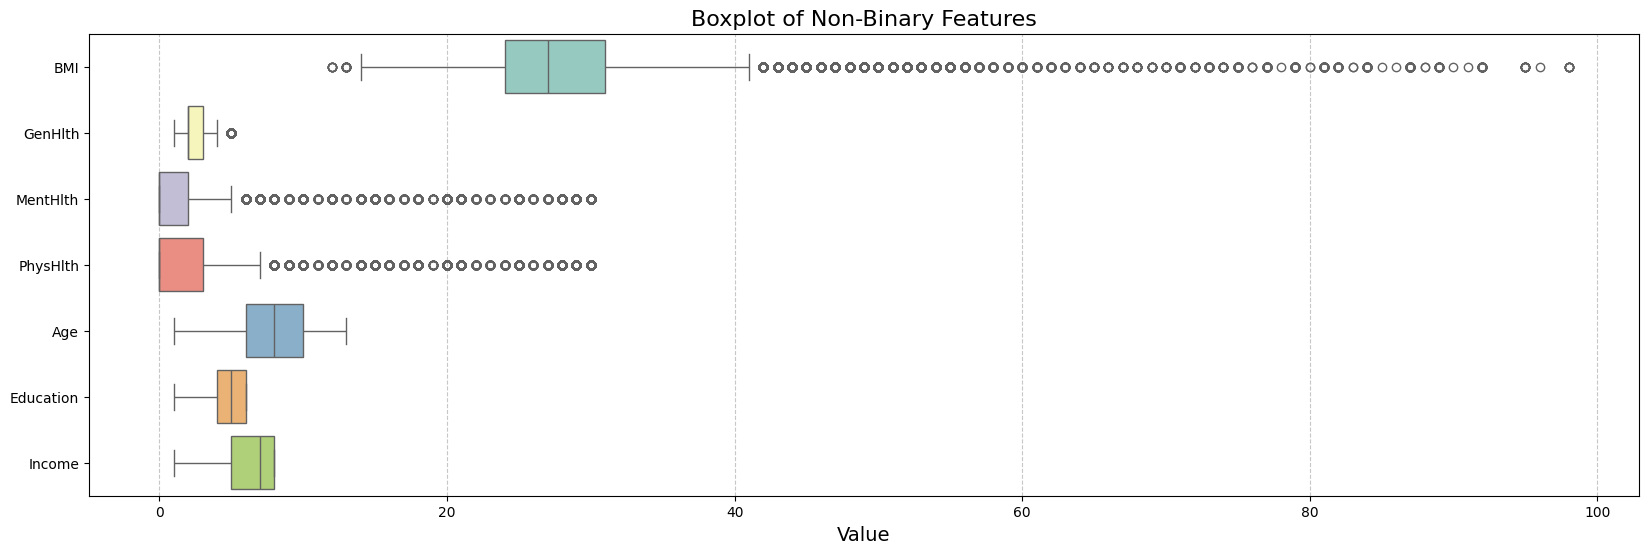

In [103]:
plt.figure(figsize=(20, 6))
sns.boxplot(data=df.loc[:, df.nunique() > 2].drop('Diabetes_012', axis=1), orient="h", palette="Set3")
plt.title("Boxplot of Non-Binary Features", fontsize=16)
plt.xlabel("Value", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

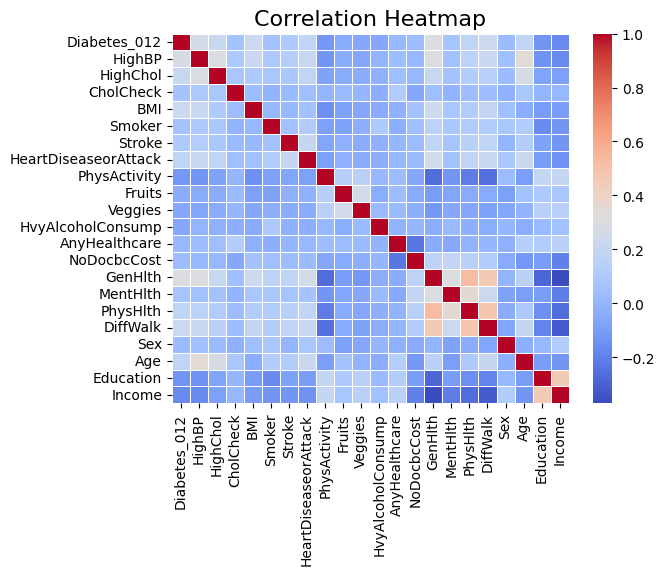

In [104]:
plt.Figure(figsize=(20, 20))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [105]:
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

pca = PCA(n_components=2)
X_red = pca.fit_transform(X)

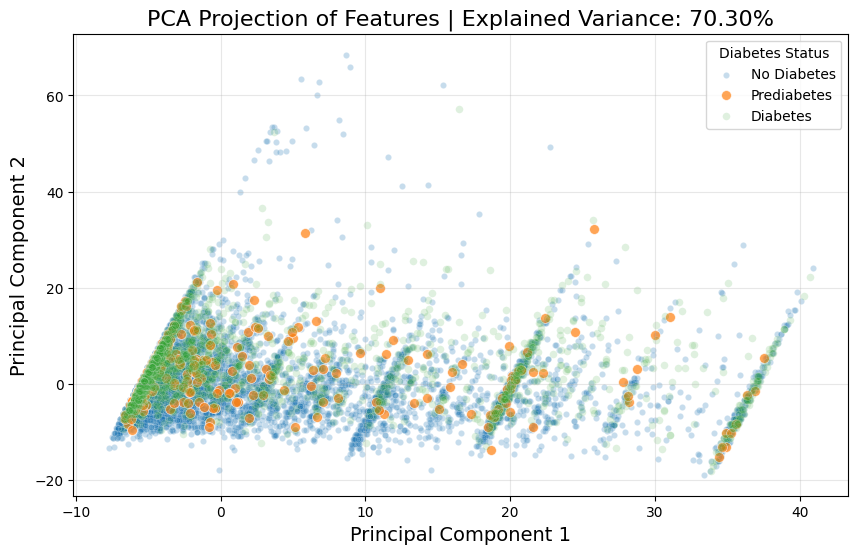

In [106]:
_, X_sample, _, y_sample = train_test_split(
    X_red, y, test_size=15000, stratify=y
)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_sample[:, 0][y_sample == 0], y=X_sample[:, 1][y_sample == 0], s=20, alpha=0.25)
sns.scatterplot(x=X_sample[:, 0][y_sample == 1], y=X_sample[:, 1][y_sample == 1], s=50, alpha=0.7)
sns.scatterplot(x=X_sample[:, 0][y_sample == 2], y=X_sample[:, 1][y_sample == 2], s=30, alpha=0.15) 
plt.title(f"PCA Projection of Features | Explained Variance: {pca.explained_variance_ratio_.sum() * 100:.2f}%", fontsize=16)
plt.xlabel("Principal Component 1", fontsize=14)
plt.ylabel("Principal Component 2", fontsize=14)
plt.legend(title="Diabetes Status", labels=["No Diabetes", "Prediabetes", "Diabetes"])
plt.grid(alpha=0.3)
plt.show()

In [107]:
pca_3d = PCA(n_components=3)
X_red_3d = pca_3d.fit_transform(X)

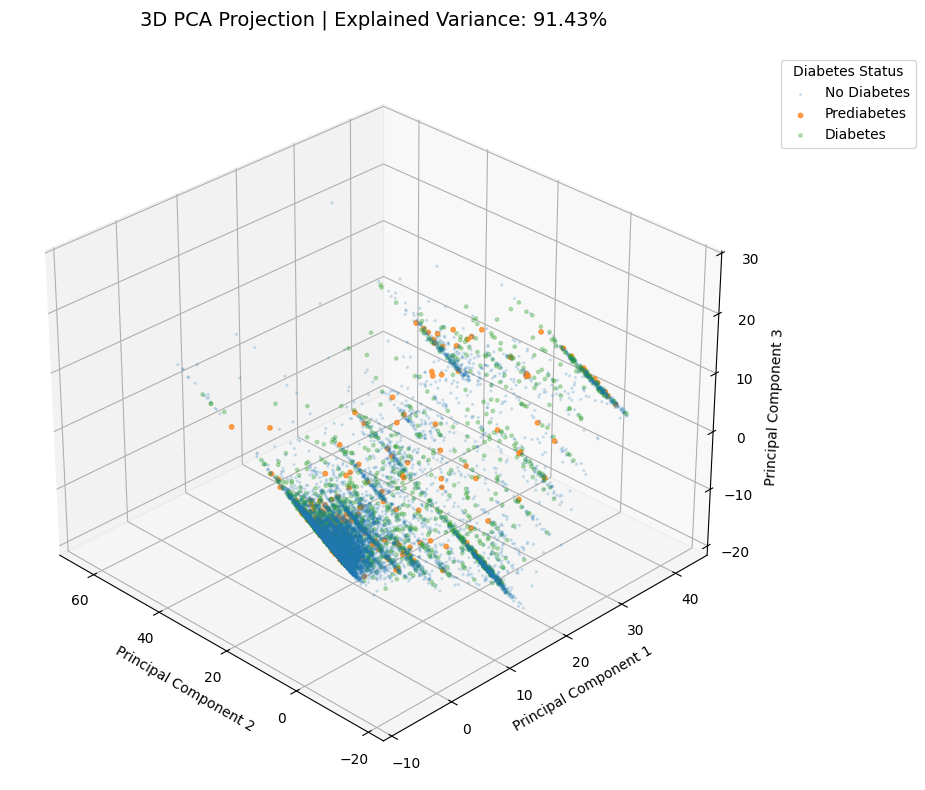

In [108]:
_, X_sample, _, y_sample = train_test_split(
    X_red_3d, y, test_size=15000, stratify=y
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_sample[:, 0][y_sample == 0], X_sample[:, 1][y_sample == 0], X_sample[:, 2][y_sample == 0], s=2, alpha=0.15, label="No Diabetes")

ax.scatter(X_sample[:, 0][y_sample == 1], X_sample[:, 1][y_sample == 1], X_sample[:, 2][y_sample == 1], s=10, alpha=0.7, label="Prediabetes")

ax.scatter(X_sample[:, 0][y_sample == 2], X_sample[:, 1][y_sample == 2], X_sample[:, 2][y_sample == 2], s=6, alpha=0.3, label="Diabetes")

ax.set_title(f"3D PCA Projection | Explained Variance: {pca_3d.explained_variance_ratio_.sum() * 100:.2f}%", fontsize=14, pad=20)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

ax.legend(title="Diabetes Status", loc="upper left", bbox_to_anchor=(1.05, 1))
ax.grid(alpha=0.2)

ax.view_init(azim=-135)
ax.zaxis._axinfo['juggled'] = (1, 2, 2)

plt.subplots_adjust(left=0.18, right=0.82)
plt.tight_layout()
plt.show()